# **1- Introduction**

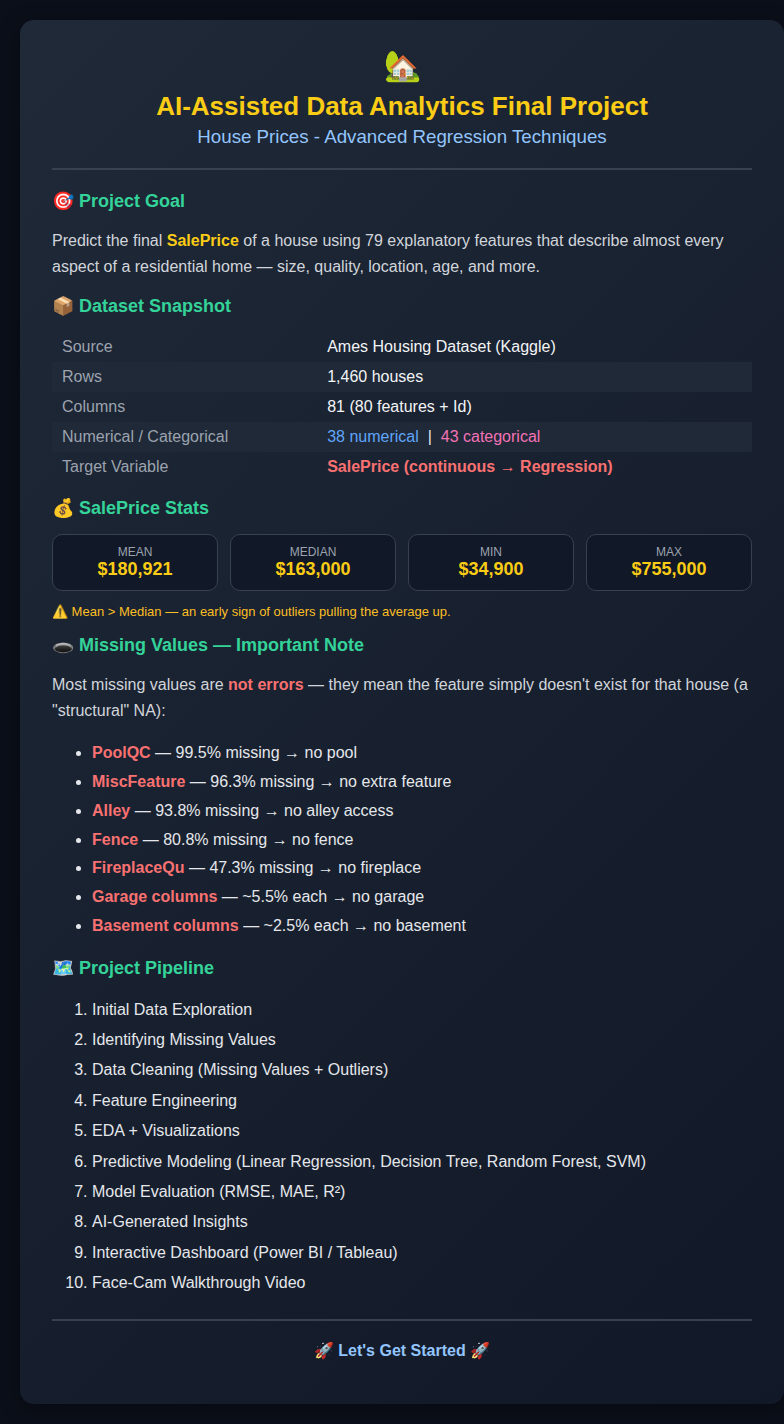

# **2- Importing Important Libraries**

In [60]:
# ================================================================================
# Libraries Used at Each Stage
# ================================================================================

# --------------------------------------------------------------------------
# 1) Initial Data Exploration
# --------------------------------------------------------------------------
import pandas as pd          # Load, inspect, and summarize the dataset
import numpy as np           # Numerical and statistical operations

# --------------------------------------------------------------------------
# 2) Identifying Missing Values
# --------------------------------------------------------------------------
# Pandas (isnull/isna) is enough to count and calculate missing percentages.
# Optional library for a visual view of missingness:
import missingno as msno     # Visual missing-value matrix / heatmap

# --------------------------------------------------------------------------
# 3) Data Cleaning (Missing Values + Outliers)
# --------------------------------------------------------------------------
from sklearn.impute import SimpleImputer   # Automated imputation (mean/median/most frequent)
from scipy import stats                    # Z-score calculation for outlier detection

# --------------------------------------------------------------------------
# 4) Feature Engineering
# --------------------------------------------------------------------------
# Pandas and NumPy are enough to create new columns (e.g., house age = YrSold - YearBuilt)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder  # Encode categorical columns

# --------------------------------------------------------------------------
# 5) EDA + Visualizations
# --------------------------------------------------------------------------
import matplotlib.pyplot as plt   # Core plotting (histograms, scatter plots, line charts)
import seaborn as sns             # Statistical visualizations (heatmaps, boxplots, correlation)

# --------------------------------------------------------------------------
# 6) Predictive Modeling
# --------------------------------------------------------------------------
from sklearn.model_selection import train_test_split   # Train/test split
from sklearn.linear_model import LinearRegression       # Linear Regression model
from sklearn.tree import DecisionTreeRegressor           # Decision Tree model
from sklearn.ensemble import RandomForestRegressor        # Random Forest model
from sklearn.svm import SVR                                # Support Vector Machine (regression)

# --------------------------------------------------------------------------
# 7) Model Evaluation
# --------------------------------------------------------------------------
from sklearn.metrics import (
    mean_squared_error,     # For MSE, and RMSE (its square root)
    mean_absolute_error,    # For MAE
    r2_score,                # For R^2 score
)

# --------------------------------------------------------------------------
# 8) AI-Generated Insights
# --------------------------------------------------------------------------
# No dedicated Python library for this step -- it is done by feeding the
# analysis and model results into an AI tool (ChatGPT / Claude) and asking
# for a natural-language summary and business recommendations.
# (Optional) To automate this step directly via API:
# import anthropic  # to call the Claude API and generate insights programmatically

# --------------------------------------------------------------------------
# General Settings (optional, improves output readability)
# --------------------------------------------------------------------------
pd.set_option("display.max_columns", None)   # Show all columns without truncation
sns.set_style("whitegrid")                    # Cleaner, consistent plot style
plt.rcParams["figure.figsize"] = (10, 6)      # Comfortable default figure size

print("All required libraries imported successfully")

All required libraries imported successfully


# **3- Loading The Dataset**

In [61]:
df = pd.read_csv('/content/train.csv')

# **4- Basic Information About Dataset**

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [63]:
df.shape

(1460, 81)

In [64]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [65]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [66]:
df.tail(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


# **5- Data Quality Assessment**

# **1. Missing Values Check**

In [67]:
# Calculate missing count and percentage for each column
missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

# Filter columns with missing values and sort descending
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(missing_data)

              Missing Count  Missing Percentage (%)
PoolQC                 1453               99.520548
MiscFeature            1406               96.301370
Alley                  1369               93.767123
Fence                  1179               80.753425
MasVnrType              872               59.726027
FireplaceQu             690               47.260274
LotFrontage             259               17.739726
GarageType               81                5.547945
GarageYrBlt              81                5.547945
GarageFinish             81                5.547945
GarageQual               81                5.547945
GarageCond               81                5.547945
BsmtExposure             38                2.602740
BsmtFinType2             38                2.602740
BsmtQual                 37                2.534247
BsmtCond                 37                2.534247
BsmtFinType1             37                2.534247
MasVnrArea                8                0.547945
Electrical  

# **2. Duplicate Rows Check**

In [68]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Display duplicate rows if any exist
if duplicate_count > 0:
    duplicates = df[df.duplicated()]
    print(duplicates)

Number of duplicate rows: 0


# **3. Completely NaN Columns Check**

In [69]:
# Find columns where all values are NaN
completely_nan_cols = [col for col in df.columns if df[col].isnull().all()]

print(f"Completely NaN columns: {completely_nan_cols}")

Completely NaN columns: []


# **4. Leading and Trailing Spaces Check**

In [70]:
# Select object (categorical) columns only
cat_cols = df.select_dtypes(include=['object']).columns

spaces_found = {}
for col in cat_cols:
    # Get unique values excluding NaN
    unique_vals = df[col].dropna().unique()
    # Check for values that change after stripping whitespace
    spaces = [v for v in unique_vals if isinstance(v, str) and (v != v.strip())]
    if spaces:
        spaces_found[col] = spaces

print("Columns with leading/trailing spaces:", spaces_found)

Columns with leading/trailing spaces: {}


# **5. Inconsistent Categories / Capitalization Check**

In [71]:
# Select object columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Total categorical columns found: {len(cat_cols)}\n")

for col in cat_cols:
    # Convert values to lowercase and compare unique counts to detect case inconsistencies
    vals = df[col].dropna().astype(str)
    lower_vals = vals.str.lower()

    # Print column name and its unique values to see the output clearly
    print(f"Checking column: '{col}' | Unique values count: {vals.nunique()}")
    print(f"Sample values: {vals.unique()[:5]}") # Show first 5 unique values as a sample

    if vals.nunique() != lower_vals.nunique():
        print(f"--> Potential inconsistency in column '{col}':")
        print(vals.unique())

    print("-" * 40)

Total categorical columns found: 43

Checking column: 'MSZoning' | Unique values count: 5
Sample values: ['RL' 'RM' 'C (all)' 'FV' 'RH']
----------------------------------------
Checking column: 'Street' | Unique values count: 2
Sample values: ['Pave' 'Grvl']
----------------------------------------
Checking column: 'Alley' | Unique values count: 2
Sample values: ['Grvl' 'Pave']
----------------------------------------
Checking column: 'LotShape' | Unique values count: 4
Sample values: ['Reg' 'IR1' 'IR2' 'IR3']
----------------------------------------
Checking column: 'LandContour' | Unique values count: 4
Sample values: ['Lvl' 'Bnk' 'Low' 'HLS']
----------------------------------------
Checking column: 'Utilities' | Unique values count: 2
Sample values: ['AllPub' 'NoSeWa']
----------------------------------------
Checking column: 'LotConfig' | Unique values count: 5
Sample values: ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
----------------------------------------
Checking column: 'Land

# **6. Outliers Detection Using IQR**

In [72]:
# Select numerical columns only
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

outliers_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count values falling outside the bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        outliers_summary[col] = len(outliers)

print("Outliers count per numerical column:")
for col, count in outliers_summary.items():
    print(f"{col}: {count} outliers")

Outliers count per numerical column:
MSSubClass: 103 outliers
LotFrontage: 88 outliers
LotArea: 69 outliers
OverallQual: 2 outliers
OverallCond: 125 outliers
YearBuilt: 7 outliers
MasVnrArea: 96 outliers
BsmtFinSF1: 7 outliers
BsmtFinSF2: 167 outliers
BsmtUnfSF: 29 outliers
TotalBsmtSF: 61 outliers
1stFlrSF: 20 outliers
2ndFlrSF: 2 outliers
LowQualFinSF: 26 outliers
GrLivArea: 31 outliers
BsmtFullBath: 1 outliers
BsmtHalfBath: 82 outliers
BedroomAbvGr: 35 outliers
KitchenAbvGr: 68 outliers
TotRmsAbvGrd: 30 outliers
Fireplaces: 5 outliers
GarageCars: 5 outliers
GarageArea: 21 outliers
WoodDeckSF: 32 outliers
OpenPorchSF: 77 outliers
EnclosedPorch: 208 outliers
3SsnPorch: 24 outliers
ScreenPorch: 116 outliers
PoolArea: 7 outliers
MiscVal: 52 outliers
SalePrice: 61 outliers


# **7. Data Types Inspection**

In [73]:
# Check and display the data type of each column
print("--- Data Types for Each Column ---")
print(df.dtypes)

print("\n" + "="*40 + "\n")

# Summary of data types count (how many columns per data type)
print("--- Summary of Data Types Count ---")
print(df.dtypes.value_counts())

--- Data Types for Each Column ---
Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


--- Summary of Data Types Count ---
object     43
int64      35
float64     3
Name: count, dtype: int64


# **6- Data Cleaning**

# **1: Handling Missing Values (Domain-Specific Imputation)**

In [74]:
# 1. Fill missing values with 'None' for categorical features where NaN means the feature doesn't exist
none_cols = ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('No_Feature')

# 2. Fill missing values with 0 for numerical garage, basement, or masonry areas/counts
zero_cols = ['GarageYrBlt', 'MasVnrArea', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'GarageCars', 'GarageArea']
for col in zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 3. Fill small missing counts using Mode (for Electrical) or Median (for LotFrontage)
if 'Electrical' in df.columns:
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

# Verify total remaining missing values in the dataframe
print("Total remaining missing values in the dataframe:", df.isnull().sum().sum())

# Save the fully cleaned dataframe to a new CSV file
output_file_name = 'cleaned_train.csv'
df.to_csv(output_file_name, index=False)

print(f"File successfully cleaned and saved as '{output_file_name}'!")

Total remaining missing values in the dataframe: 0
File successfully cleaned and saved as 'cleaned_train.csv'!


# **2: Duplicate Rows Check & Removal**

In [75]:
# Check for duplicate rows
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

# Remove duplicates if any exist
if duplicates_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows have been removed.")
else:
    print("No duplicates to remove.")

Number of duplicate rows found: 0
No duplicates to remove.


# **3: Completely NaN Columns Check & Removal**

In [76]:
# Find completely NaN columns
completely_nan_cols = [col for col in df.columns if df[col].isnull().all()]

print(f"Completely NaN columns: {completely_nan_cols}")

# Drop them if any exist
if completely_nan_cols:
    df = df.drop(columns=completely_nan_cols)
    print("Completely NaN columns dropped.")
else:
    print("No completely NaN columns found to drop.")

Completely NaN columns: []
No completely NaN columns found to drop.


# **4: Leading and Trailing Spaces Cleaning**

In [77]:
# Select object (categorical) columns
cat_cols = df.select_dtypes(include=['object']).columns

# Strip leading and trailing spaces from string values
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()

print("Leading and trailing spaces cleaned from categorical columns.")

Leading and trailing spaces cleaned from categorical columns.


# **5: Inconsistent Categories Standardization**


In [78]:
# Select object columns and standardize text casing if needed to merge inconsistencies
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    # Example: converting to title case or lowercase to ensure consistency if variations exist
    # df[col] = df[col].str.title()
    pass

print("Categorical columns checked for consistency.")

Categorical columns checked for consistency.


# **6: Outliers Review & Management (Domain-Based Filtering)**

In [79]:
# In housing data, extreme values (like high LotArea or SalePrice) are often genuine mansions/luxury homes.
# Instead of deleting them blindly, we flag them or keep them as valid real-world data points.
# Here we calculate bounds using IQR for demonstration on GrLivArea:

col = 'GrLivArea'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify natural outliers
natural_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"Identified {len(natural_outliers)} outliers in '{col}'. Kept as valid natural variations (luxury properties).")

Identified 31 outliers in 'GrLivArea'. Kept as valid natural variations (luxury properties).


# **7: Correcting Data Types**

In [80]:
# Some numerical columns are actually categorical codes (e.g., MSSubClass)
if 'MSSubClass' in df.columns:
    df['MSSubClass'] = df['MSSubClass'].astype(str)

# Convert specific year or numerical flags to appropriate types if required
if 'YrSold' in df.columns:
    df['YrSold'] = df['YrSold'].astype(str)

print("Data types corrected successfully.")
print(df[['MSSubClass', 'YrSold']].dtypes)

Data types corrected successfully.
MSSubClass    object
YrSold        object
dtype: object


# **7- Feature Engineering**

In [81]:
df["HouseAge"] = df["YrSold"].astype(int) - df["YearBuilt"]

In [82]:
# Years since the house was last remodeled (before sale)
df["YearsSinceRemodel"] = df["YrSold"].astype(int) - df["YearRemodAdd"]

In [83]:
# Total living area combining basement, first floor, and second floor
df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

In [84]:
# Combine all bathroom columns into one total (half baths count as 0.5)
df["TotalBathrooms"] = (df["FullBath"] + 0.5 * df["HalfBath"] +
                         df["BsmtFullBath"].fillna(0) + 0.5 * df["BsmtHalfBath"].fillna(0))

In [85]:
# Flag whether the house was ever remodeled (1 = yes, 0 = no)
df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

In [86]:
# Simplify rare detailed columns into simple Yes/No flags
df["HasPool"] = (df["PoolArea"] > 0).astype(int)
df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)

In [87]:
# List of all newly engineered features
new_features = ["HouseAge", "YearsSinceRemodel", "TotalSF", "TotalBathrooms",
                 "IsRemodeled", "HasPool", "HasGarage", "HasFireplace"]

print("New dataset shape:", df.shape)
print("\nSummary statistics for new features:")
print(df[new_features].describe())
print("\nFirst 5 rows of new features:")
print(df[new_features].head())

New dataset shape: (1460, 89)

Summary statistics for new features:
          HouseAge  YearsSinceRemodel       TotalSF  TotalBathrooms  \
count  1460.000000        1460.000000   1460.000000     1460.000000   
mean     36.547945          22.950000   2567.048630        2.210616   
std      30.250152          20.640653    821.714421        0.785399   
min       0.000000          -1.000000    334.000000        1.000000   
25%       8.000000           4.000000   2009.500000        2.000000   
50%      35.000000          14.000000   2474.000000        2.000000   
75%      54.000000          41.000000   3004.000000        2.500000   
max     136.000000          60.000000  11752.000000        6.000000   

       IsRemodeled      HasPool    HasGarage  HasFireplace  
count  1460.000000  1460.000000  1460.000000   1460.000000  
mean      0.476712     0.004795     0.944521      0.527397  
std       0.499629     0.069100     0.228992      0.499420  
min       0.000000     0.000000     0.000000    

In [88]:
print("Number of columns:", len(df.columns))

Number of columns: 89


In [89]:
# Final check
print("Final dataset shape:", df.shape)
print("Number of columns:", len(df.columns))

# Save cleaned + feature engineered dataset
df.to_csv('/content/train_cleaned_featured.csv', index=False)

print("\nDataset saved successfully!")

Final dataset shape: (1460, 89)
Number of columns: 89

Dataset saved successfully!


# **8- Statistics**

# **Descriptive Statistics**

=== DESCRIPTIVE STATISTICS SUMMARY ===
           SalePrice    GrLivArea        LotArea  TotalBsmtSF
count    1460.000000  1460.000000    1460.000000  1460.000000
mean   180921.195890  1515.463699   10516.828082  1057.429452
std     79442.502883   525.480383    9981.264932   438.705324
min     34900.000000   334.000000    1300.000000     0.000000
25%    129975.000000  1129.500000    7553.500000   795.750000
50%    163000.000000  1464.000000    9478.500000   991.500000
75%    214000.000000  1776.750000   11601.500000  1298.250000
max    755000.000000  5642.000000  215245.000000  6110.000000


/tmp/ipykernel_533/1559952199.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[1], palette='Set2')


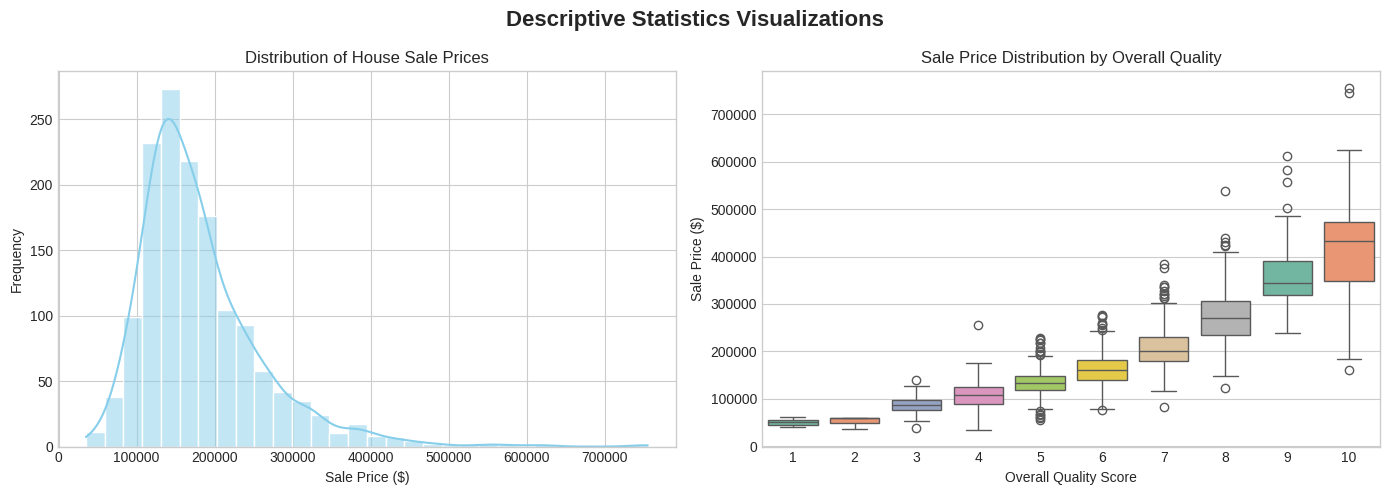

In [90]:
# 1. Calculate Descriptive Statistics for key numerical columns
desc_stats = df[['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF']].describe()
print("=== DESCRIPTIVE STATISTICS SUMMARY ===")
print(desc_stats)

# 2. Plotting Descriptive Visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Descriptive Statistics Visualizations', fontsize=16, fontweight='bold')

# Chart 1: Distribution (Histogram & KDE) of SalePrice
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title('Distribution of House Sale Prices')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

# Chart 2: Boxplot of SalePrice across Overall Quality
sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[1], palette='Set2')
axes[1].set_title('Sale Price Distribution by Overall Quality')
axes[1].set_xlabel('Overall Quality Score')
axes[1].set_ylabel('Sale Price ($)')

plt.tight_layout()
plt.show()

# **Inferential Statistics & Relationships**

=== INFERENTIAL STATISTICS (CORRELATION MATRIX) ===
             SalePrice  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  \
SalePrice     1.000000     0.790982   0.708624    0.640409     0.613581   
OverallQual   0.790982     1.000000   0.593007    0.600671     0.537808   
GrLivArea     0.708624     0.593007   1.000000    0.467247     0.454868   
GarageCars    0.640409     0.600671   0.467247    1.000000     0.434585   
TotalBsmtSF   0.613581     0.537808   0.454868    0.434585     1.000000   
YearBuilt     0.522897     0.572323   0.199010    0.537850     0.391452   

             YearBuilt  
SalePrice     0.522897  
OverallQual   0.572323  
GrLivArea     0.199010  
GarageCars    0.537850  
TotalBsmtSF   0.391452  
YearBuilt     1.000000  


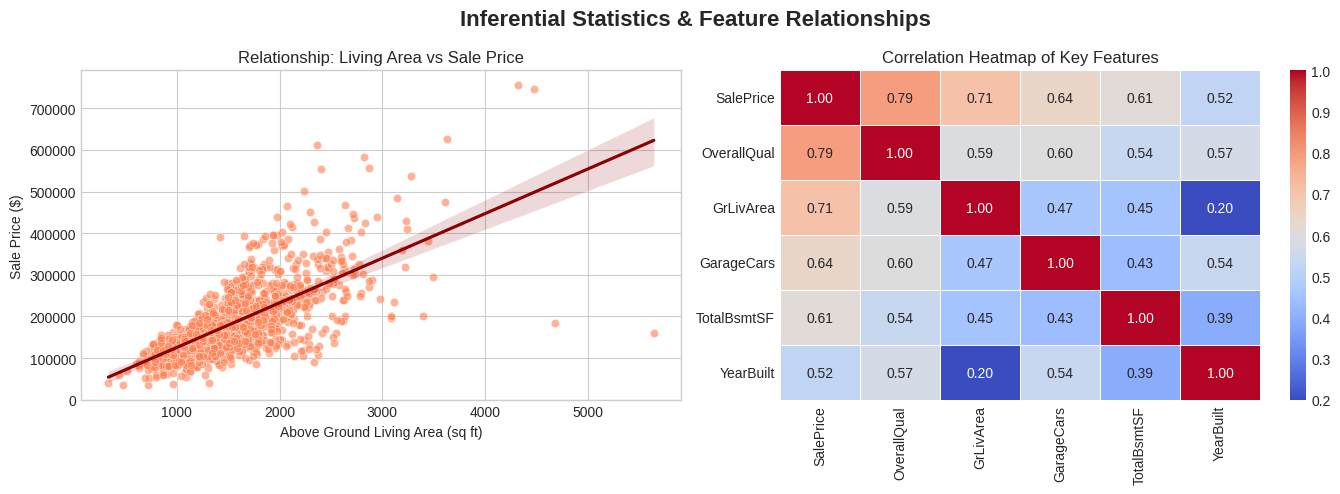

In [91]:
# 1. Calculate Inferential Statistics (Correlation Matrix)
key_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'YearBuilt']
corr_matrix = df[key_cols].corr()
print("=== INFERENTIAL STATISTICS (CORRELATION MATRIX) ===")
print(corr_matrix)

# 2. Plotting Inferential Visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Inferential Statistics & Feature Relationships', fontsize=16, fontweight='bold')

# Chart 1: Scatter Plot with Regression Line (Living Area vs SalePrice)
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', ax=axes[0], color='coral', alpha=0.6)
sns.regplot(data=df, x='GrLivArea', y='SalePrice', ax=axes[0], scatter=False, color='darkred')
axes[0].set_title('Relationship: Living Area vs Sale Price')
axes[0].set_xlabel('Above Ground Living Area (sq ft)')
axes[0].set_ylabel('Sale Price ($)')

# Chart 2: Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlation Heatmap of Key Features')

plt.tight_layout()
plt.show()

# **9- Predictive Modeling**

# **Features & Target**

In [92]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("train_cleaned_featured.csv")

# Select the strongest numeric features correlated with SalePrice
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "LotArea",
    "Fireplaces",
    "OpenPorchSF",
    "HouseAge",
    "TotalSF",
    "TotalBathrooms",
    "IsRemodeled",
    "HasGarage",
    "HasFireplace"
]

X = df[features].copy()

# Fill any missing values with the column median
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

# Original target (continuous numeric)
y_regression = df["SalePrice"]

# Convert price into two classes: Low / High based on the median
median_price = y_regression.median()
# Instead of mapping to "Low"/"High" text labels, map directly to 0/1
y_classification = (y_regression > median_price).astype(int)
# 0 = Low price, 1 = High price

print("Median SalePrice:", median_price)
print(y_classification.value_counts())

Median SalePrice: 163000.0
SalePrice
0    732
1    728
Name: count, dtype: int64


# **Train/Test Split + Scaling**

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

# Standardize features (needed for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1168, 17)
Test shape: (292, 17)


# **Logistic Regression**

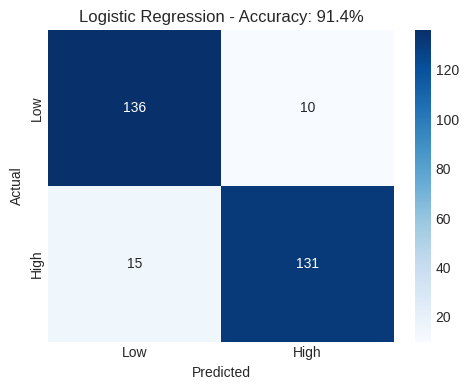

Logistic Regression Accuracy: 91.44 %


In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, log_pred)
log_cm = confusion_matrix(y_test, log_pred, labels=[0, 1])

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(log_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "High"], yticklabels=["Low", "High"])
plt.title(f"Logistic Regression - Accuracy: {log_accuracy*100:.1f}%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("Logistic Regression Accuracy:", round(log_accuracy * 100, 2), "%")

# **Decision Tree**

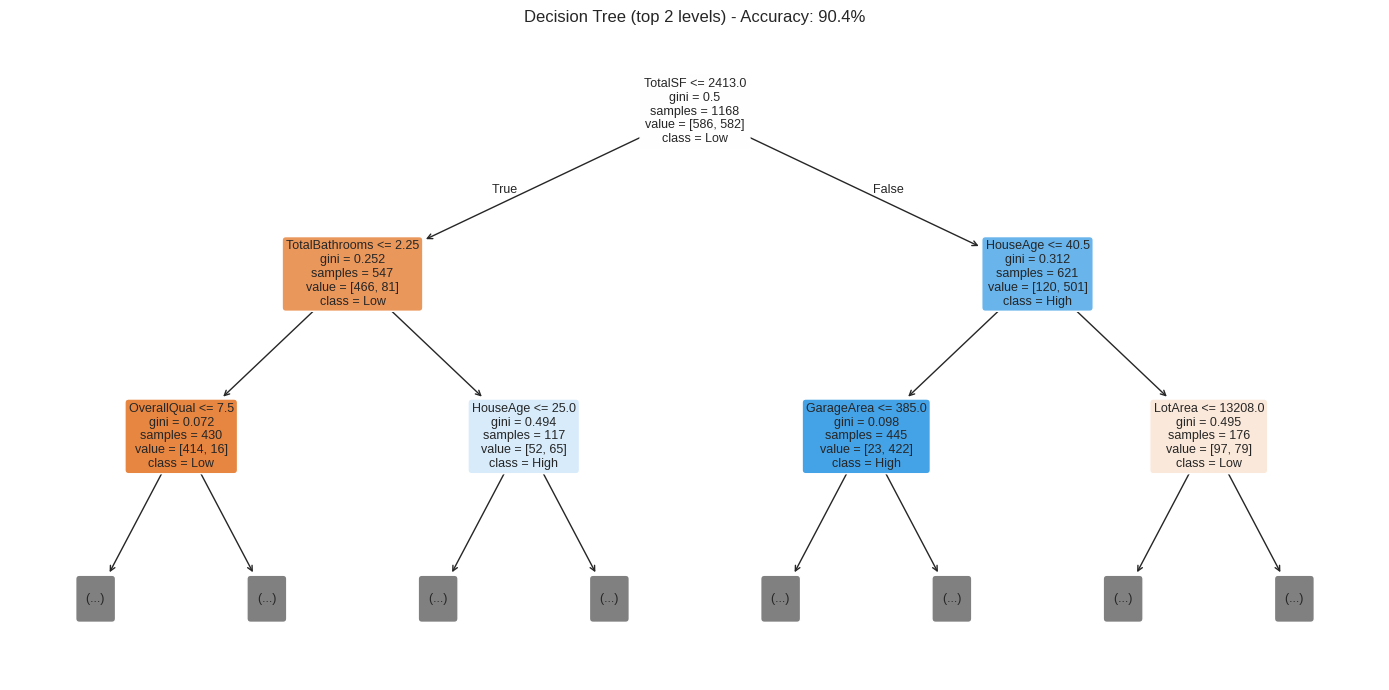

Decision Tree Accuracy: 90.41 %


In [95]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_model = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

# Plot the actual tree structure (first 2 levels for readability)
plt.figure(figsize=(14, 7))
plot_tree(dt_model, max_depth=2, feature_names=features, class_names=["Low", "High"],
          filled=True, rounded=True, fontsize=9)
plt.title(f"Decision Tree (top 2 levels) - Accuracy: {dt_accuracy*100:.1f}%")
plt.tight_layout()
plt.show()

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

# **Random Forest**

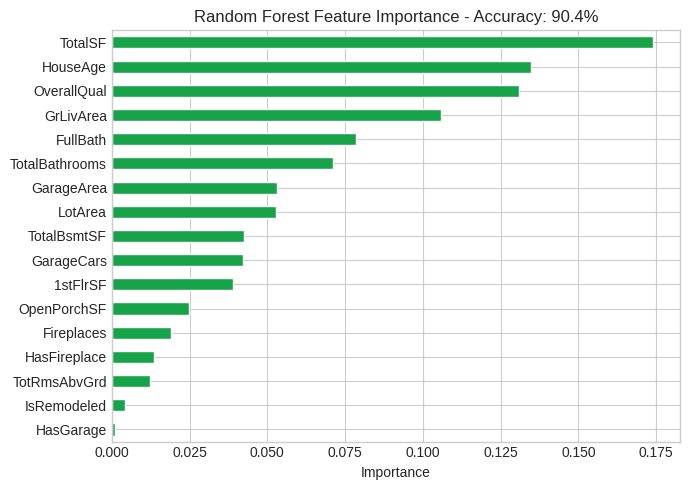

Random Forest Accuracy: 90.41 %


In [96]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

# Plot which features the forest relied on most
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(7, 5))
importances.plot(kind="barh", color="#16a34a")
plt.title(f"Random Forest Feature Importance - Accuracy: {rf_accuracy*100:.1f}%")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

# **SVM**

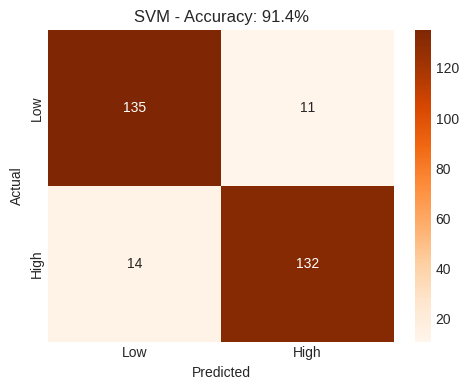

SVM Accuracy: 91.44 %


In [97]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_cm = confusion_matrix(y_test, svm_pred, labels=[0, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(svm_cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Low", "High"], yticklabels=["Low", "High"])
plt.title(f"SVM - Accuracy: {svm_accuracy*100:.1f}%")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")

# **Linear Regression**

Linear Regression Results
------------------------------
R² Score: 0.804
MAE: 24503.71
RMSE: 38758.18


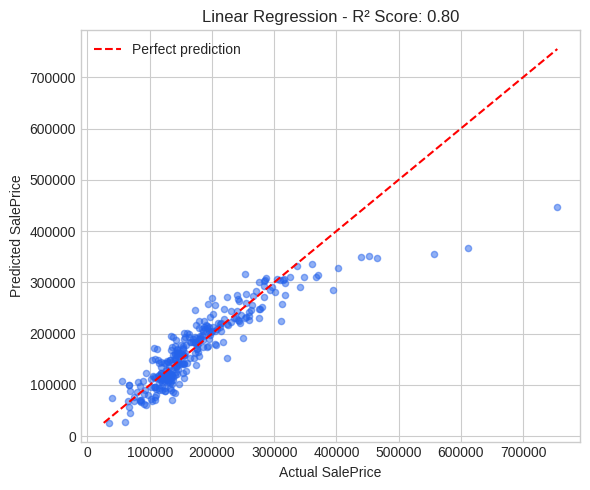

In [98]:
# Features used for Regression
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "LotArea",
    "Fireplaces",
    "OpenPorchSF",
    "HouseAge",
    "TotalSF",
    "TotalBathrooms",
    "IsRemodeled",
    "HasGarage",
    "HasFireplace"
]

# Input features and target
X = df[features].copy()
y_regression = df["SalePrice"]

# Train / Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_regression,
    test_size=0.2,
    random_state=42
)

# Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train_r, y_train_r)

# Predictions
lin_pred = lin_model.predict(X_test_r)

# Evaluation Metrics
r2 = r2_score(y_test_r, lin_pred)
mae = mean_absolute_error(y_test_r, lin_pred)
rmse = np.sqrt(mean_squared_error(y_test_r, lin_pred))

# Print results
print("Linear Regression Results")
print("-" * 30)
print("R² Score:", round(r2, 3))
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

# Actual vs Predicted Plot
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test_r,
    lin_pred,
    alpha=0.5,
    color="#2563eb",
    s=20
)

# Perfect prediction line
lims = [
    min(y_test_r.min(), lin_pred.min()),
    max(y_test_r.max(), lin_pred.max())
]

plt.plot(
    lims,
    lims,
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title(f"Linear Regression - R² Score: {r2:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

# **A final comparison of all models.**

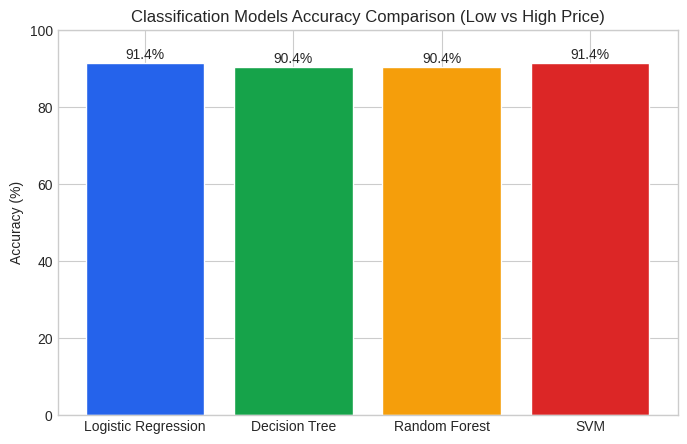


Summary Table:
Logistic Regression: 91.44%
Decision Tree: 90.41%
Random Forest: 90.41%
SVM: 91.44%


In [99]:
import matplotlib.pyplot as plt

results = {
    "Logistic Regression": log_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "SVM": svm_accuracy,
}

plt.figure(figsize=(8, 5))
bars = plt.bar(results.keys(), [v * 100 for v in results.values()], color=["#2563eb","#16a34a","#f59e0b","#dc2626"])
plt.ylabel("Accuracy (%)")
plt.title("Classification Models Accuracy Comparison (Low vs High Price)")
plt.ylim(0, 100)
for bar, v in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, v*100 + 1, f"{v*100:.1f}%", ha="center")
plt.show()

print("\nSummary Table:")
for name, acc in results.items():
    print(f"{name}: {acc*100:.2f}%")

# **10- ERD**

In [100]:
# Reload the cleaned + feature engineered dataset directly to avoid depending on execution order
df = pd.read_csv('/content/train_cleaned_featured.csv')

# 2. Main Fact Table (Properties)
fact_properties = df[[
    'Id', 'SalePrice', 'LotFrontage', 'LotArea', 'GrLivArea', 'TotalSF',
    'YearBuilt', 'YearRemodAdd', 'HouseAge', 'YearsSinceRemodel', 'MoSold', 'YrSold',
]].copy()
fact_properties.to_csv('Fact_Properties.csv', index=False)

# 3. Location Dimension Table (Dim_Location)
dim_location = df[[
    'Id', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
    'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
]].copy()
dim_location.rename(columns={'Id': 'Property_ID'}, inplace=True)
dim_location.to_csv('Dim_Location.csv', index=False)

# 4. Garage Dimension Table (Dim_Garage)
dim_garage = df[[
    'Id', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea',
    'GarageQual', 'GarageCond', 'PavedDrive', 'HasGarage',
]].copy()
dim_garage.rename(columns={'Id': 'Property_ID'}, inplace=True)
dim_garage.to_csv('Dim_Garage.csv', index=False)

# 5. Basement Dimension Table (Dim_Basement)
dim_basement = df[[
    'Id', 'TotalBsmtSF', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'BsmtFullBath',
    'BsmtHalfBath', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
]].copy()
dim_basement.rename(columns={'Id': 'Property_ID'}, inplace=True)
dim_basement.to_csv('Dim_Basement.csv', index=False)

# 6. Quality and Ratings Dimension Table (Dim_Quality)
dim_quality = df[[
    'Id', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond', 'KitchenQual',
    'FireplaceQu', 'TotalBathrooms', 'IsRemodeled',
]].copy()
dim_quality.rename(columns={'Id': 'Property_ID'}, inplace=True)
dim_quality.to_csv('Dim_Quality.csv', index=False)

print('Data successfully split and Star Schema tables created!')

Data successfully split and Star Schema tables created!


# **11- Data Modeling & Relational Database Architecture**

In [101]:
from sqlalchemy import create_engine, Column, Integer, String, Float, ForeignKey
from sqlalchemy.orm import declarative_base, relationship, sessionmaker
import pandas as pd

engine = create_engine('sqlite:///housing_database.db', echo=False)
Base = declarative_base()

class Property(Base):
    __tablename__ = 'Fact_Properties'
    Property_ID = Column('Id', Integer, primary_key=True)
    SalePrice = Column(Float)
    LotFrontage = Column(Float)
    LotArea = Column(Float)
    GrLivArea = Column(Float)
    TotalSF = Column(Float)
    YearBuilt = Column(Integer)
    YearRemodAdd = Column(Integer)
    HouseAge = Column(Integer)
    YearsSinceRemodel = Column(Integer)
    MoSold = Column(Integer)
    YrSold = Column(Integer)
    location = relationship('Location', back_populates='property', uselist=False)
    garage = relationship('Garage', back_populates='property', uselist=False)
    basement = relationship('Basement', back_populates='property', uselist=False)
    quality = relationship('Quality', back_populates='property', uselist=False)

class Location(Base):
    __tablename__ = 'Dim_Location'
    Property_ID = Column(Integer, ForeignKey('Fact_Properties.Id'), primary_key=True)
    MSZoning = Column(String)
    Street = Column(String)
    Alley = Column(String)
    LotShape = Column(String)
    LandContour = Column(String)
    Utilities = Column(String)
    LotConfig = Column(String)
    LandSlope = Column(String)
    Neighborhood = Column(String)
    Condition1 = Column(String)
    Condition2 = Column(String)
    property = relationship('Property', back_populates='location')

class Garage(Base):
    __tablename__ = 'Dim_Garage'
    Property_ID = Column(Integer, ForeignKey('Fact_Properties.Id'), primary_key=True)
    GarageType = Column(String)
    GarageYrBlt = Column(Float)
    GarageFinish = Column(String)
    GarageCars = Column(Integer)
    GarageArea = Column(Float)
    GarageQual = Column(String)
    GarageCond = Column(String)
    PavedDrive = Column(String)
    HasGarage = Column(Integer)
    property = relationship('Property', back_populates='garage')

class Basement(Base):
    __tablename__ = 'Dim_Basement'
    Property_ID = Column(Integer, ForeignKey('Fact_Properties.Id'), primary_key=True)
    TotalBsmtSF = Column(Float)
    BsmtFinSF1 = Column(Float)
    BsmtFinSF2 = Column(Float)
    BsmtUnfSF = Column(Float)
    BsmtFullBath = Column(Integer)
    BsmtHalfBath = Column(Integer)
    BsmtQual = Column(String)
    BsmtCond = Column(String)
    BsmtExposure = Column(String)
    BsmtFinType1 = Column(String)
    BsmtFinType2 = Column(String)
    property = relationship('Property', back_populates='basement')

class Quality(Base):
    __tablename__ = 'Dim_Quality'
    Property_ID = Column(Integer, ForeignKey('Fact_Properties.Id'), primary_key=True)
    OverallQual = Column(Integer)
    OverallCond = Column(Integer)
    ExterQual = Column(String)
    ExterCond = Column(String)
    KitchenQual = Column(String)
    FireplaceQu = Column(String)
    TotalBathrooms = Column(Float)
    IsRemodeled = Column(Integer)
    property = relationship('Property', back_populates='quality')

Base.metadata.create_all(engine)
print('Database tables created successfully via SQLAlchemy ORM!')

Session = sessionmaker(bind=engine)
session = Session()

fact_properties = pd.read_csv('Fact_Properties.csv')
dim_location = pd.read_csv('Dim_Location.csv')
dim_garage = pd.read_csv('Dim_Garage.csv')
dim_basement = pd.read_csv('Dim_Basement.csv')
dim_quality = pd.read_csv('Dim_Quality.csv')

fact_properties.to_sql('Fact_Properties', engine, if_exists='replace', index=False)
dim_location.to_sql('Dim_Location', engine, if_exists='replace', index=False)
dim_garage.to_sql('Dim_Garage', engine, if_exists='replace', index=False)
dim_basement.to_sql('Dim_Basement', engine, if_exists='replace', index=False)
dim_quality.to_sql('Dim_Quality', engine, if_exists='replace', index=False)

print('Database populated with data!')
session.commit()
session.close()
engine.dispose()
print('Database connection closed.')

Database tables created successfully via SQLAlchemy ORM!
Database populated with data!
Database connection closed.


# **12- Schema Creation & Data Seeding**

In [102]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('housing_database.db')
cursor = conn.cursor()

fact_properties = pd.read_csv('Fact_Properties.csv')
dim_location = pd.read_csv('Dim_Location.csv')
dim_garage = pd.read_csv('Dim_Garage.csv')
dim_basement = pd.read_csv('Dim_Basement.csv')
dim_quality = pd.read_csv('Dim_Quality.csv')

fact_properties.to_sql('Fact_Properties', conn, if_exists='replace', index=False)
dim_location.to_sql('Dim_Location', conn, if_exists='replace', index=False)
dim_garage.to_sql('Dim_Garage', conn, if_exists='replace', index=False)
dim_basement.to_sql('Dim_Basement', conn, if_exists='replace', index=False)
dim_quality.to_sql('Dim_Quality', conn, if_exists='replace', index=False)

print('All tables successfully loaded into SQLite database!')

query = """
SELECT
    f.Id,
    f.SalePrice,
    l.Neighborhood,
    g.GarageArea,
    q.OverallQual,
    b.TotalBsmtSF
FROM Fact_Properties f
JOIN Dim_Location l ON f.Id = l.Property_ID
JOIN Dim_Garage g ON f.Id = g.Property_ID
JOIN Dim_Quality q ON f.Id = q.Property_ID
JOIN Dim_Basement b ON f.Id = b.Property_ID
LIMIT 5;
"""

result_df = pd.read_sql(query, conn)
print('\nSample query results (Joined Data):')
print(result_df)

conn.close()

All tables successfully loaded into SQLite database!

Sample query results (Joined Data):
   Id  SalePrice Neighborhood  GarageArea  OverallQual  TotalBsmtSF
0   1     208500      CollgCr         548            7          856
1   2     181500      Veenker         460            6         1262
2   3     223500      CollgCr         608            7          920
3   4     140000      Crawfor         642            7          756
4   5     250000      NoRidge         836            8         1145


# **13- Data Analysis**

# **House Age vs Sale Price**

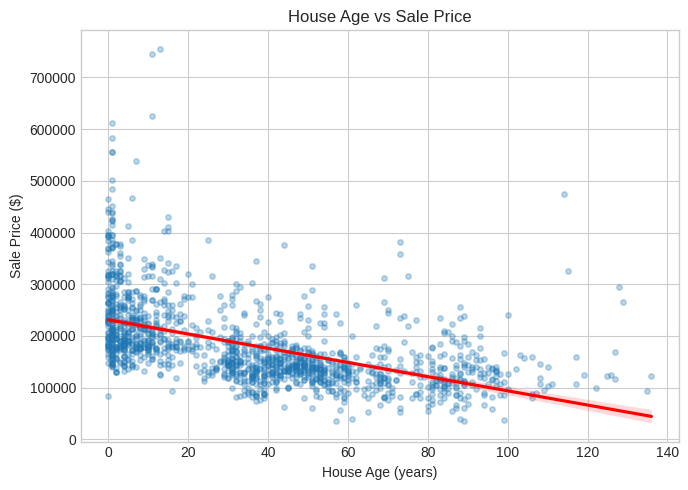

Correlation: -0.523350417546816


In [103]:
# Relationship between house age and sale price
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="HouseAge", y="SalePrice",
            scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "red"})
plt.title("House Age vs Sale Price")
plt.xlabel("House Age (years)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.show()

print("Correlation:", df["HouseAge"].corr(df["SalePrice"]))

# **Total Square Footage vs Sale Price**

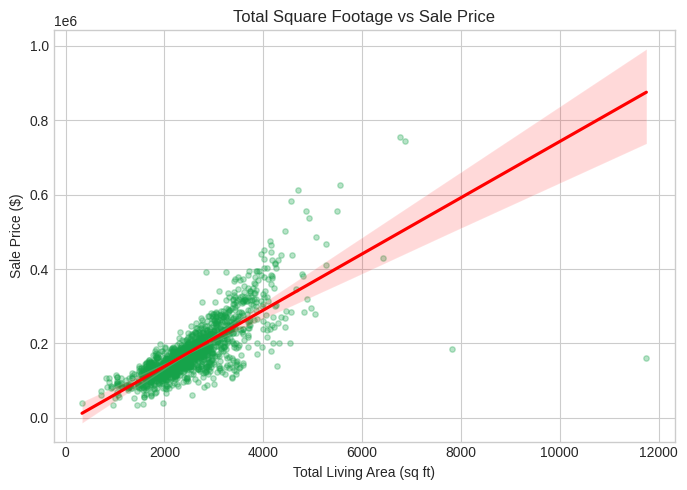

Correlation: 0.7822600527979846


In [104]:
plt.figure(figsize=(7, 5))
sns.regplot(data=df, x="TotalSF", y="SalePrice",
            scatter_kws={"alpha": 0.3, "s": 15, "color": "#16a34a"}, line_kws={"color": "red"})
plt.title("Total Square Footage vs Sale Price")
plt.xlabel("Total Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.show()

print("Correlation:", df["TotalSF"].corr(df["SalePrice"]))

# **Top 10 Neighborhoods by Average Sale Price**

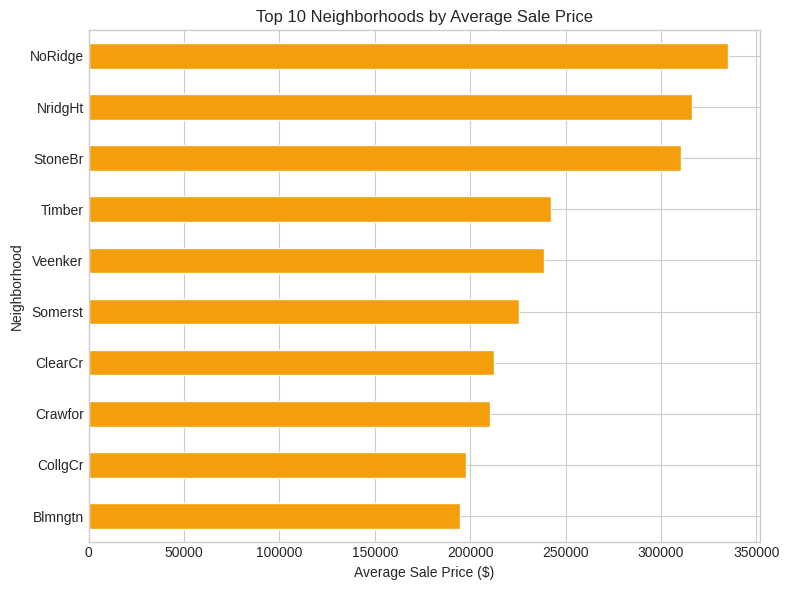

In [105]:
neigh_price = df.groupby("Neighborhood")["SalePrice"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
neigh_price.head(10).plot(kind="barh", color="#f59e0b")
plt.title("Top 10 Neighborhoods by Average Sale Price")
plt.xlabel("Average Sale Price ($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# **Correlation of Engineered Features with SalePrice**

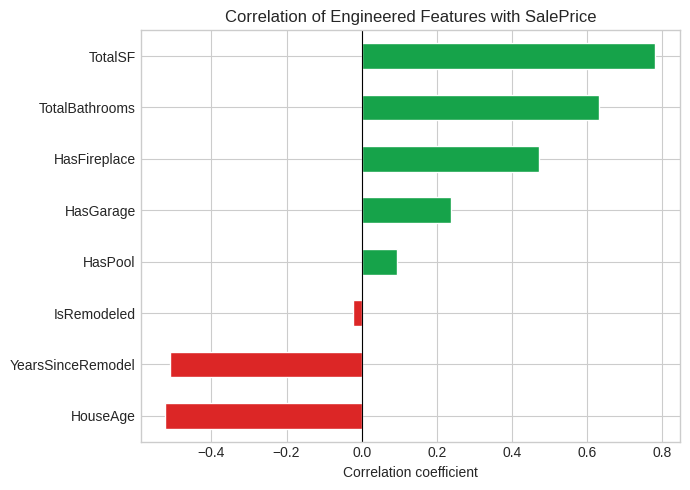

In [106]:
engineered = ["HouseAge", "YearsSinceRemodel", "TotalSF", "TotalBathrooms",
              "IsRemodeled", "HasPool", "HasGarage", "HasFireplace", "SalePrice"]
corr_eng = df[engineered].corr()["SalePrice"].drop("SalePrice").sort_values()

plt.figure(figsize=(7, 5))
colors = ["#dc2626" if v < 0 else "#16a34a" for v in corr_eng.values]
corr_eng.plot(kind="barh", color=colors)
plt.title("Correlation of Engineered Features with SalePrice")
plt.xlabel("Correlation coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

## **14- Isights & Recommendations**

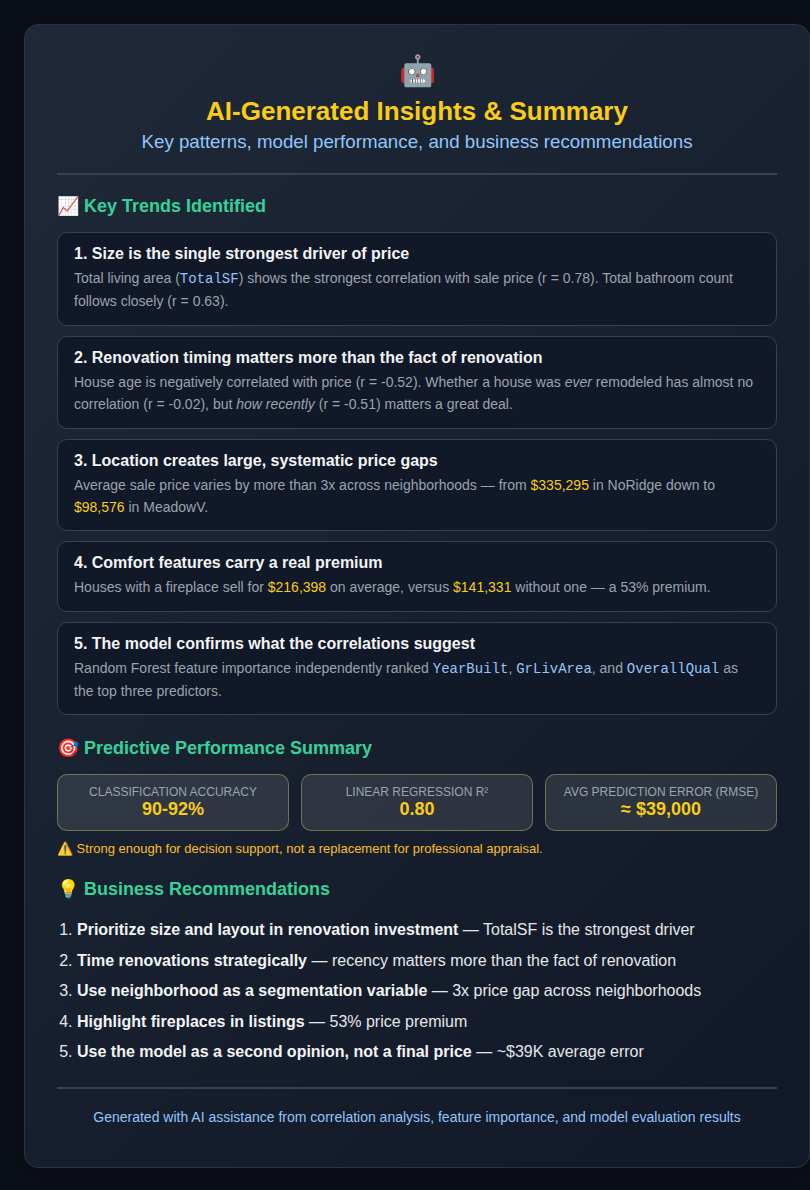